# Adult Census Income : Préparation des données, segmentation et classification

**Idée directrice :** ne pas commencer par un algorithme. Commencer par comprendre le problème, les données et ce que révèle l'exploration, puis justifier chaque choix de préparation avant de modéliser.

**Interprétation :** ce notebook suit la démarche CRISP-DM : on comprend d'abord l'objectif et le dataset (**Adult / Census Income**, UCI, recensement américain de 1994, 48 842 personnes), puis on prépare les données, et seulement ensuite on applique la segmentation et la classification.

## Feuille de route

1. **Business Understanding** : quel problème cherche-t-on à résoudre ?
2. **Data Understanding** : quelles données avons-nous ?
3. **Data Exploration** : que nous disent les chiffres et les graphiques ?
4. **Data Preparation**
   - 4.1 Nettoyage de base (`?`, libellés de la cible, doublons)
   - 4.2 Valeurs manquantes
   - 4.3 Regroupement de catégories
   - 4.4 Feature engineering (gains et pertes en capital)
   - 4.5 Suppression de colonnes
   - 4.6 Redondance entre `relationship` et `marital-status`
   - 4.7 Valeurs extrêmes
   - 4.8 Encodage et mise à l'échelle
   - 4.9 Export des données préparées (livrable)
5. **Segmentation** (K-Means) : quels profils socio-économiques existent dans la population ?
6. **Classification** : peut-on prédire si le revenu dépasse 50 000 $ ?
7. **Évaluation et interprétation des résultats**

**Interprétation :** la feuille de route sépare les étapes de l'analyse pour que chacune ait un objectif clair avant de passer à la suivante. Chaque transformation de la section 4 s'appuie sur une observation de la section 3, et les résultats des sections 5 et 6 sont évalués avec des métriques adaptées à une cible déséquilibrée (76 % / 24 %).

**Livrable :** le fichier `adult_prepared.csv`, qui contient les données nettoyées et préparées après l'ensemble des transformations.

# 1. Business Understanding

## Contexte
Le dataset **Adult (Census Income)**, issu du dépôt UCI Machine Learning Repository, provient du recensement américain de 1994. Chaque ligne décrit une personne adulte (âge, niveau d'études, profession, situation familiale, heures travaillées, etc.) et indique si son revenu annuel dépasse 50 000 $.

## Problématiques
1. **Segmentation (clustering)** : identifier des profils socio-économiques homogènes dans la population, sans utiliser la variable cible.
2. **Classification** : prédire si une personne gagne plus de 50K$ par an (`income`) à partir de ses caractéristiques.

## Intérêt
Comprendre les facteurs associés aux hauts revenus, et mesurer dans quelle mesure un modèle peut les prédire. L'objectif méthodologique du lab est aussi de montrer, étape par étape, l'impact de la préparation des données sur la qualité des résultats.

## Critères de réussite
- Données nettoyées et chaque choix de préparation justifié.
- Segments interprétables (méthode du coude et score de silhouette comme repères, l'interprétabilité tranchant le choix de k).
- Classifieurs évalués avec des métriques adaptées à une cible déséquilibrée (F1-score, rappel, ROC-AUC, PR-AUC) et pas seulement l'accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week",
        "native-country", "income"]


In [2]:
train = pd.read_csv("adult/adult.data", names=cols, skipinitialspace=True)
test  = pd.read_csv("adult/adult.test", names=cols, skipinitialspace=True, skiprows=1)

print(train.shape, test.shape)

(32561, 15) (16281, 15)


In [3]:
train["source"] = "train"
test["source"] = "test"

df = pd.concat([train, test], ignore_index=True)
df.to_csv("adult/adult_raw.csv", index=False) 

print(df.shape)

(48842, 16)


# 2. Data Understanding

## Chargement des données
Les fichiers originaux `adult.data` (32 561 lignes) et `adult.test` (16 281 lignes) ont été chargés puis fusionnés, soit **48 842 observations**. Une colonne `source` conserve l'origine de chaque ligne afin de pouvoir retrouver le découpage officiel train/test. Les fichiers n'ayant pas d'en-tête, les noms de colonnes ont été définis à partir du fichier `adult.names`. Une copie brute (`adult_raw.csv`) a été sauvegardée pour pouvoir revenir en arrière.

In [4]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,source
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
 15  source          48842 non-null  object
dtypes: int64(6), object(10)
memory usage: 6.0+ MB


## Structure du dataset
Le dataset contient **16 colonnes** : 15 colonnes d'origine plus la colonne technique `source`.

- **6 variables numériques** : `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`.
- **8 variables catégorielles** : `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`.
- **La cible** : `income` (`<=50K` ou `>50K`).

⚠️ `info()` n'indique aucune valeur manquante, mais c'est trompeur : les valeurs manquantes sont encodées par la chaîne de caractères `?`, que pandas ne reconnaît pas comme manquante. Elles sont analysées dans la section suivante.

In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Statistiques descriptives
- **`age`** : de 17 à 90 ans (moyenne ≈ 38,6 ; médiane 37). Population adulte uniquement.
- **`fnlwgt`** : poids d'échantillonnage du recensement. Ce n'est pas une caractéristique de la personne, et son échelle est très grande (jusqu'à ≈ 1,49 million).
- **`education-num`** : de 1 à 16. C'est un encodage ordinal de `education`, donc les deux colonnes sont redondantes.
- **`capital-gain` / `capital-loss`** : au moins 75 % de valeurs nulles, mais des maximums très élevés (99 999 et 4 356) : distributions extrêmement asymétriques.
- **`hours-per-week`** : de 1 à 99 ; le 1er quartile et la médiane valent tous deux 40 h, ce qui indique un pic sur la semaine de travail standard.

In [7]:
(df == "?").sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
source               0
dtype: int64

# 3. Data Exploration

## 3.1 Valeurs manquantes cachées (`?`)
Trois variables catégorielles contiennent des `?` :

| Variable | Nombre de `?` | % |
|---|---|---|
| `workclass` | 2 799 | ≈ 5,7 % |
| `occupation` | 2 809 | ≈ 5,8 % |
| `native-country` | 857 | ≈ 1,8 % |

Toutes les autres colonnes sont complètes. Le taux de valeurs manquantes reste faible (< 6 %), mais leur traitement devra être justifié.

In [8]:
((df == "?").sum() / len(df) * 100).round(2)

age               0.00
workclass         5.73
fnlwgt            0.00
education         0.00
education-num     0.00
marital-status    0.00
occupation        5.75
relationship      0.00
race              0.00
sex               0.00
capital-gain      0.00
capital-loss      0.00
hours-per-week    0.00
native-country    1.75
income            0.00
source            0.00
dtype: float64

In [9]:
mask_wc = df["workclass"] == "?"
mask_oc = df["occupation"] == "?"

print("Both missing:          ", (mask_wc & mask_oc).sum())
print("Only workclass missing:", (mask_wc & ~mask_oc).sum())
print("Only occupation missing:", (~mask_wc & mask_oc).sum())

Both missing:           2799
Only workclass missing: 0
Only occupation missing: 10


In [10]:
# 1. The 10 "occupation only" rows: what is their workclass?
print(df.loc[~mask_wc & mask_oc, "workclass"].value_counts())

workclass
Never-worked    10
Name: count, dtype: int64


## 3.2 Structure des valeurs manquantes
Les 2 799 lignes dont `workclass` est manquant ont **aussi** `occupation` manquant. Les 10 lignes supplémentaires où seul `occupation` manque ont toutes `workclass = Never-worked` : ce sont des personnes qui n'ont jamais travaillé, donc il ne s'agit pas d'erreurs de saisie.

L'absence d'information est donc **structurelle** et non aléatoire.

In [11]:
# 2. Compare rows with and without missing workclass/occupation
df["has_missing_job"] = mask_wc | mask_oc

print(df.groupby("has_missing_job")["income"].value_counts(normalize=True).round(3))
print(df.groupby("has_missing_job")[["age", "hours-per-week"]].mean().round(1))

has_missing_job  income
False            <=50K     0.501
                 <=50K.    0.251
                 >50K      0.166
                 >50K.     0.082
True             <=50K     0.588
                 <=50K.    0.318
                 >50K      0.068
                 >50K.     0.026
Name: proportion, dtype: float64
                  age  hours-per-week
has_missing_job                      
False            38.6            40.9
True             40.1            31.8


## 3.3 Les valeurs manquantes sont-elles liées au revenu ?

| | `<=50K` | `>50K` | Heures/semaine (moy.) |
|---|---|---|---|
| Information professionnelle présente | 75,2 % | 24,8 % | 40,9 |
| Information professionnelle manquante | 90,6 % | 9,4 % | 31,8 |

Les lignes à information manquante gagnent beaucoup moins souvent plus de 50K (9,4 % contre 24,8 %) et travaillent environ 9 heures de moins par semaine. Hypothèse : cette population regroupe en partie des personnes sans emploi ou en dehors du marché du travail, ce qui reste à vérifier.

**Conséquence pour la préparation** : supprimer ces lignes retirerait une partie spécifique de la population et biaiserait l'analyse, et une imputation par le mode (`Private`) les ferait passer à tort pour des salariés du privé. Le choix de la modalité `Unknown` est à discuter dans la section 4.

In [12]:
income_clean = df["income"].str.rstrip(".")

print(income_clean.value_counts(normalize=True).round(3))
print()
print(pd.crosstab(df["has_missing_job"], income_clean, normalize="index").round(3))

income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64

income           <=50K   >50K
has_missing_job              
False            0.752  0.248
True             0.906  0.094


## 3.4 Qualité de la cible et équilibre des classes
Dans le fichier `adult.test`, les libellés de la cible se terminent par un point (`<=50K.`, `>50K.`) : une même classe apparaît donc sous deux noms. Ce défaut devra être corrigé lors du nettoyage.

Une fois les libellés harmonisés, la répartition est de **76,1 % pour `<=50K` et 23,9 % pour `>50K`** : un déséquilibre modéré. Un modèle qui prédirait toujours `<=50K` atteindrait ≈ 76 % d'accuracy sans rien apprendre, donc l'accuracy seule sera trompeuse. Il faudra utiliser une séparation stratifiée et des métriques comme le F1-score, le rappel et le ROC-AUC.

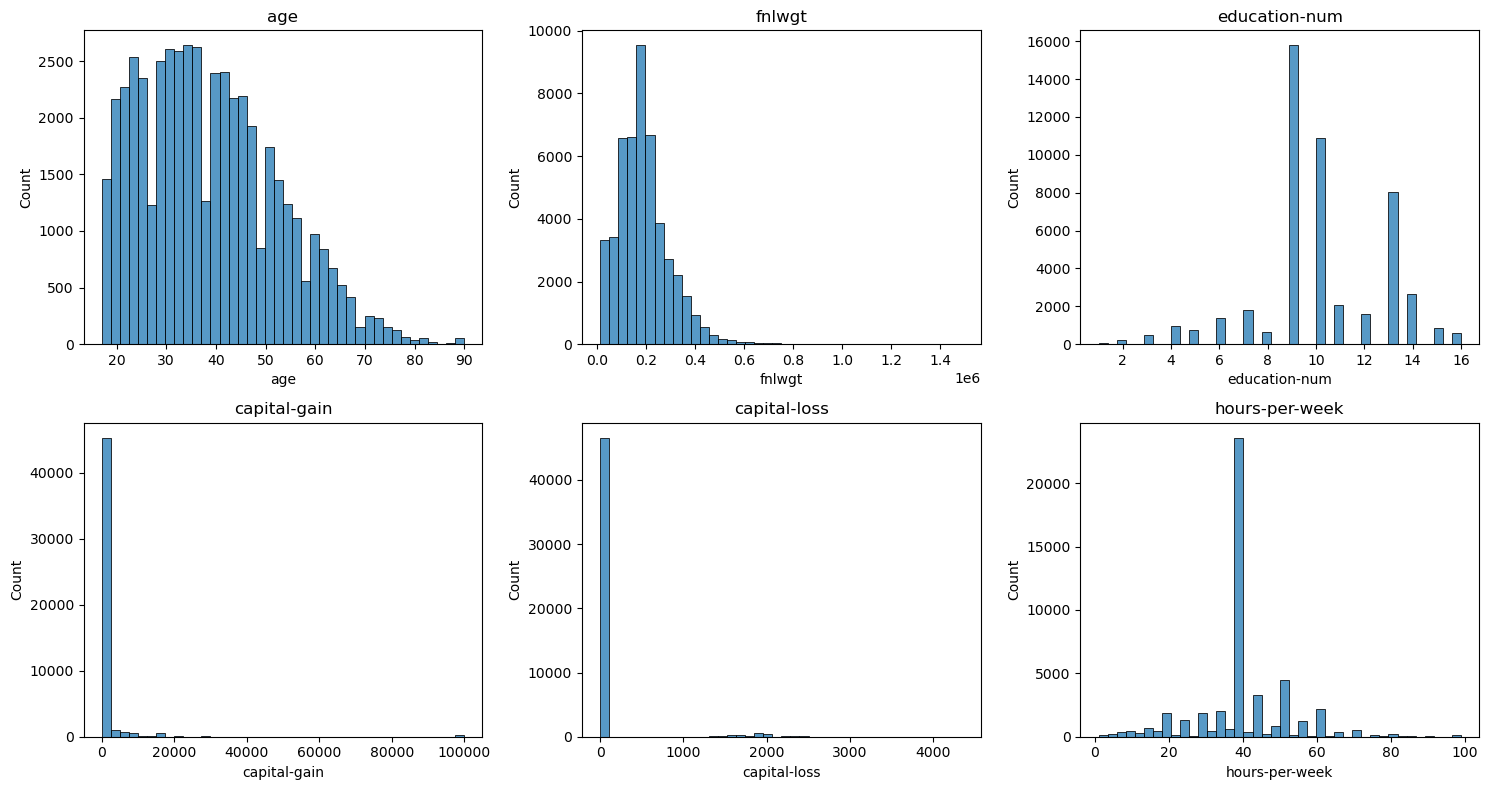

In [13]:
num_cols = ["age", "fnlwgt", "education-num",
            "capital-gain", "capital-loss", "hours-per-week"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 3.5 Distribution des variables numériques
- **`age`** : légèrement asymétrique à droite, concentrée entre 20 et 50 ans. Un petit pic à 90 ans suggère que les âges élevés sont plafonnés à 90.
- **`fnlwgt`** : fortement asymétrique à droite, avec une longue traîne.
- **`education-num`** : variable discrète et ordinale, avec des pics à 9 (HS-grad), 10 (Some-college) et 13 (Bachelors).
- **`capital-gain` / `capital-loss`** : presque toutes les valeurs sont à 0. Pour `capital-gain`, un petit groupe isolé apparaît à 99 999.
- **`hours-per-week`** : pic très marqué à 40 h (semaine standard), avec des pics secondaires à 20, 50 et 60 h. Ce pic reflète la réalité et n'est pas une anomalie.

In [14]:
# Share of zeros in the capital variables
print("Zeros capital-gain:", ((df["capital-gain"] == 0).mean() * 100).round(1), "%")
print("Zeros capital-loss:", ((df["capital-loss"] == 0).mean() * 100).round(1), "%")

# The suspicious 99999 value
print("capital-gain == 99999:", (df["capital-gain"] == 99999).sum())

# Skewness of each numeric variable
print(df[num_cols].skew().round(2))

Zeros capital-gain: 91.7 %
Zeros capital-loss: 95.3 %
capital-gain == 99999: 244
age                0.56
fnlwgt             1.44
education-num     -0.32
capital-gain      11.89
capital-loss       4.57
hours-per-week     0.24
dtype: float64


## 3.6 Quantification de l'asymétrie
- 91,7 % des valeurs de `capital-gain` et 95,3 % de `capital-loss` sont nulles.
- 244 lignes (≈ 0,5 %) ont `capital-gain = 99999`.

| Variable | Skewness | Lecture |
|---|---|---|
| `capital-gain` | 11,89 | extrême |
| `capital-loss` | 4,57 | très forte |
| `fnlwgt` | 1,44 | forte |
| `age` | 0,56 | modérée |
| `education-num` | -0,32 | quasi symétrique |
| `hours-per-week` | 0,24 | faible |

Les variables `capital-gain`, `capital-loss` et `fnlwgt` sont des candidates à une transformation (par exemple `log1p`) ou à un traitement spécifique.

In [15]:
df = df.drop(columns="has_missing_job")

In [16]:
cat_cols = ["workclass", "education", "marital-status", "occupation",
            "relationship", "race", "sex", "native-country"]

df[cat_cols].nunique()

workclass          9
education         16
marital-status     7
occupation        15
relationship       6
race               5
sex                2
native-country    42
dtype: int64

In [17]:
for col in cat_cols:
    print(df[col].value_counts(normalize=True).mul(100).round(1))
    print()

workclass
Private             69.4
Self-emp-not-inc     7.9
Local-gov            6.4
?                    5.7
State-gov            4.1
Self-emp-inc         3.5
Federal-gov          2.9
Without-pay          0.0
Never-worked         0.0
Name: proportion, dtype: float64

education
HS-grad         32.3
Some-college    22.3
Bachelors       16.4
Masters          5.4
Assoc-voc        4.2
11th             3.7
Assoc-acdm       3.3
10th             2.8
7th-8th          2.0
Prof-school      1.7
9th              1.5
12th             1.3
Doctorate        1.2
5th-6th          1.0
1st-4th          0.5
Preschool        0.2
Name: proportion, dtype: float64

marital-status
Married-civ-spouse       45.8
Never-married            33.0
Divorced                 13.6
Separated                 3.1
Widowed                   3.1
Married-spouse-absent     1.3
Married-AF-spouse         0.1
Name: proportion, dtype: float64

occupation
Prof-specialty       12.6
Craft-repair         12.5
Exec-managerial      12.5
Adm

## 3.7 Variables catégorielles
- `nunique()` compte `?` comme une modalité : les nombres réels de catégories sont 8 (`workclass`), 14 (`occupation`) et 41 (`native-country`).
- **`workclass`** : `Private` domine (69,4 %). `Without-pay` et `Never-worked` sont quasi vides.
- **`education`** : 16 modalités, version textuelle de `education-num` (redondance).
- **`marital-status`** : `Married-civ-spouse` (45,8 %) et `Never-married` (33,0 %) dominent. `Married-AF-spouse` est presque vide (0,1 %).
- **`relationship`** : recouvre `marital-status` et `sex` (`Husband` / `Wife` impliquent le mariage et le genre).
- **`occupation`** : assez équilibrée, sauf `Armed-Forces` et `Priv-house-serv` (très rares).
- **`race` / `sex`** : 85,5 % de White et 66,8 % d'hommes. L'échantillon est déséquilibré, ce qui sera à garder en tête pour interpréter les modèles.
- **`native-country`** : 89,7 % de `United-States` et une longue traîne d'environ 40 pays à moins de 2 % chacun. Un encodage one-hot direct créerait beaucoup de colonnes quasi vides.
- Quelques libellés comportent des fautes (`Holand-Netherlands`, `Trinadad&Tobago`, `Hong`), ce qui est sans effet sur les modèles mais à signaler comme observation de qualité.

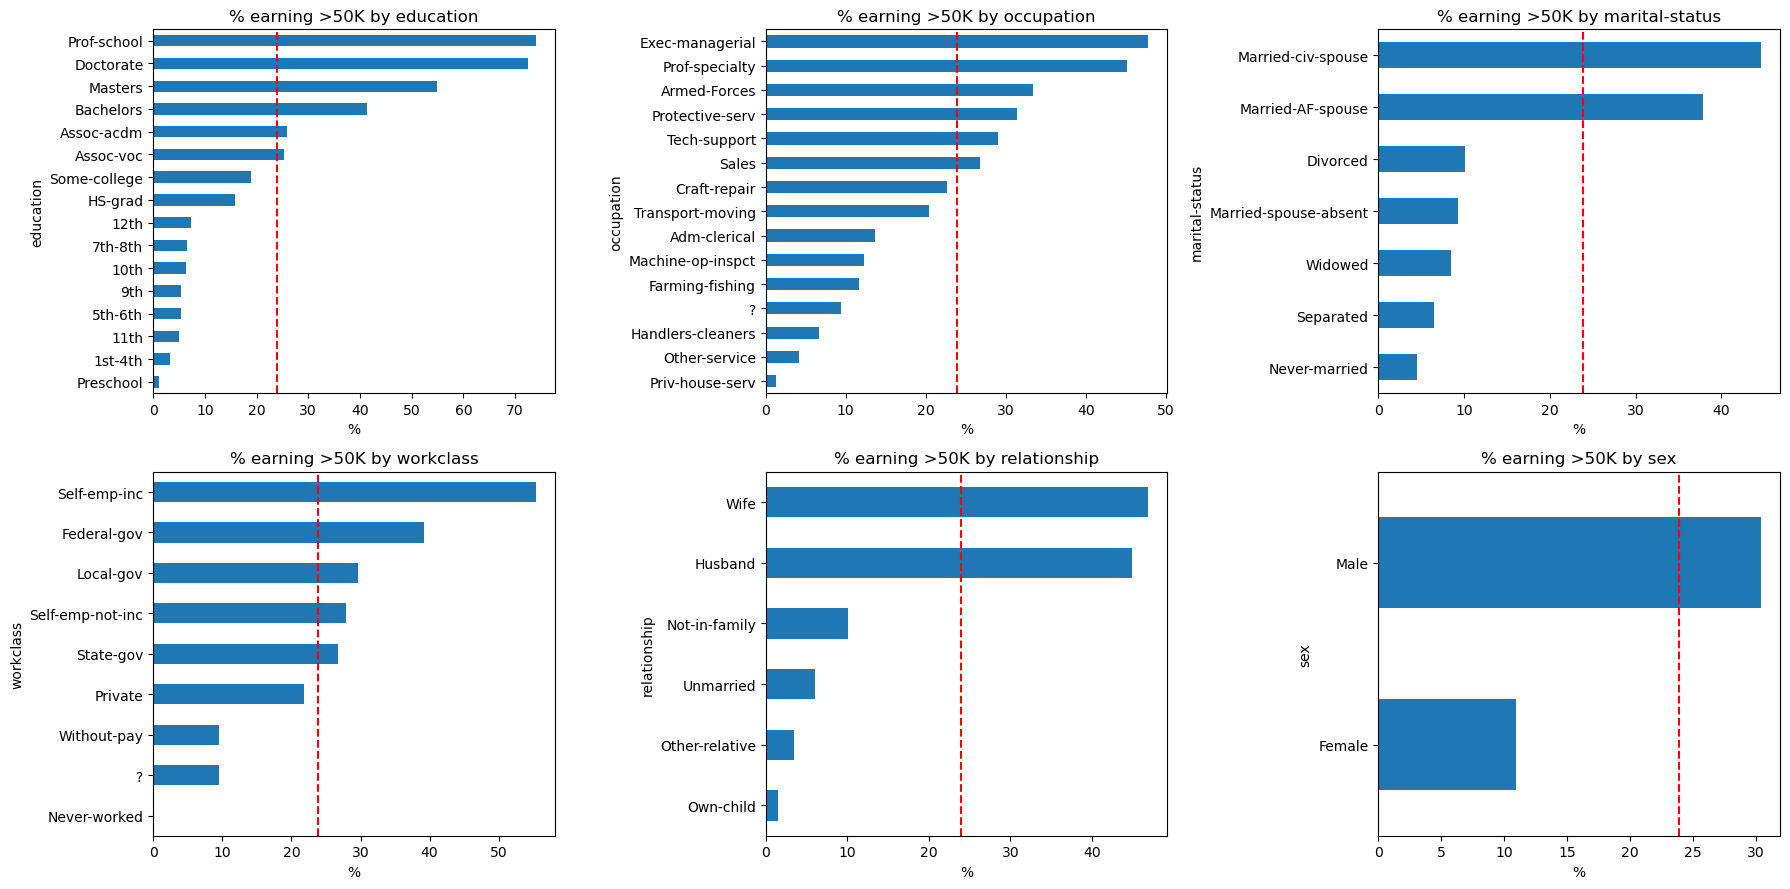

In [18]:
income_clean = df["income"].str.rstrip(".")
df_tmp = df.assign(high_income=(income_clean == ">50K").astype(int))

cols_to_plot = ["education", "occupation", "marital-status",
                "workclass", "relationship", "sex"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col in zip(axes.flat, cols_to_plot):
    rate = df_tmp.groupby(col)["high_income"].mean().sort_values() * 100
    rate.plot(kind="barh", ax=ax)
    ax.axvline(23.9, color="red", linestyle="--")   # overall average
    ax.set_title(f"% earning >50K by {col}")
    ax.set_xlabel("%")

plt.tight_layout()
plt.show()

## 3.8 Variables catégorielles et revenu
(Taux de personnes gagnant plus de 50K, à comparer à la moyenne globale de 23,9 %.)

- **`education`** : relation très nette. Prof-school (≈ 74 %) et Doctorate (≈ 73 %) dominent, suivis de Masters (≈ 55 %) et Bachelors (≈ 41 %), alors que les niveaux inférieurs au lycée restent sous 10 %.
- **`occupation`** : `Exec-managerial` (≈ 48 %) et `Prof-specialty` (≈ 45 %) en tête ; `Other-service`, `Handlers-cleaners` et `Priv-house-serv` en bas.
- **`marital-status`** : `Married-civ-spouse` (≈ 45 %) très au-dessus des autres (4 à 10 %). Une partie de l'effet vient probablement de l'âge (les célibataires sont plus jeunes).
- **`workclass`** : `Self-emp-inc` (≈ 55 %) puis `Federal-gov` (≈ 39 %).
- **`relationship`** : `Husband` et `Wife` (≈ 45 à 47 %), ce qui confirme la redondance avec `marital-status`.
- **`sex`** : ≈ 30 % des hommes contre ≈ 11 % des femmes gagnent plus de 50K. Cet écart reflète les données de 1994 et se mélange à d'autres variables (heures, profession, statut marital), donc il ne prouve pas un effet direct. Un modèle entraîné sur ces données peut le reproduire, ce qui devra être discuté dans l'interprétation.

⚠️ Les catégories très rares (`Armed-Forces`, `Married-AF-spouse`, `Never-worked`, `Without-pay`) reposent sur très peu de lignes : leurs pourcentages sont peu fiables, ce qui justifie un regroupement.

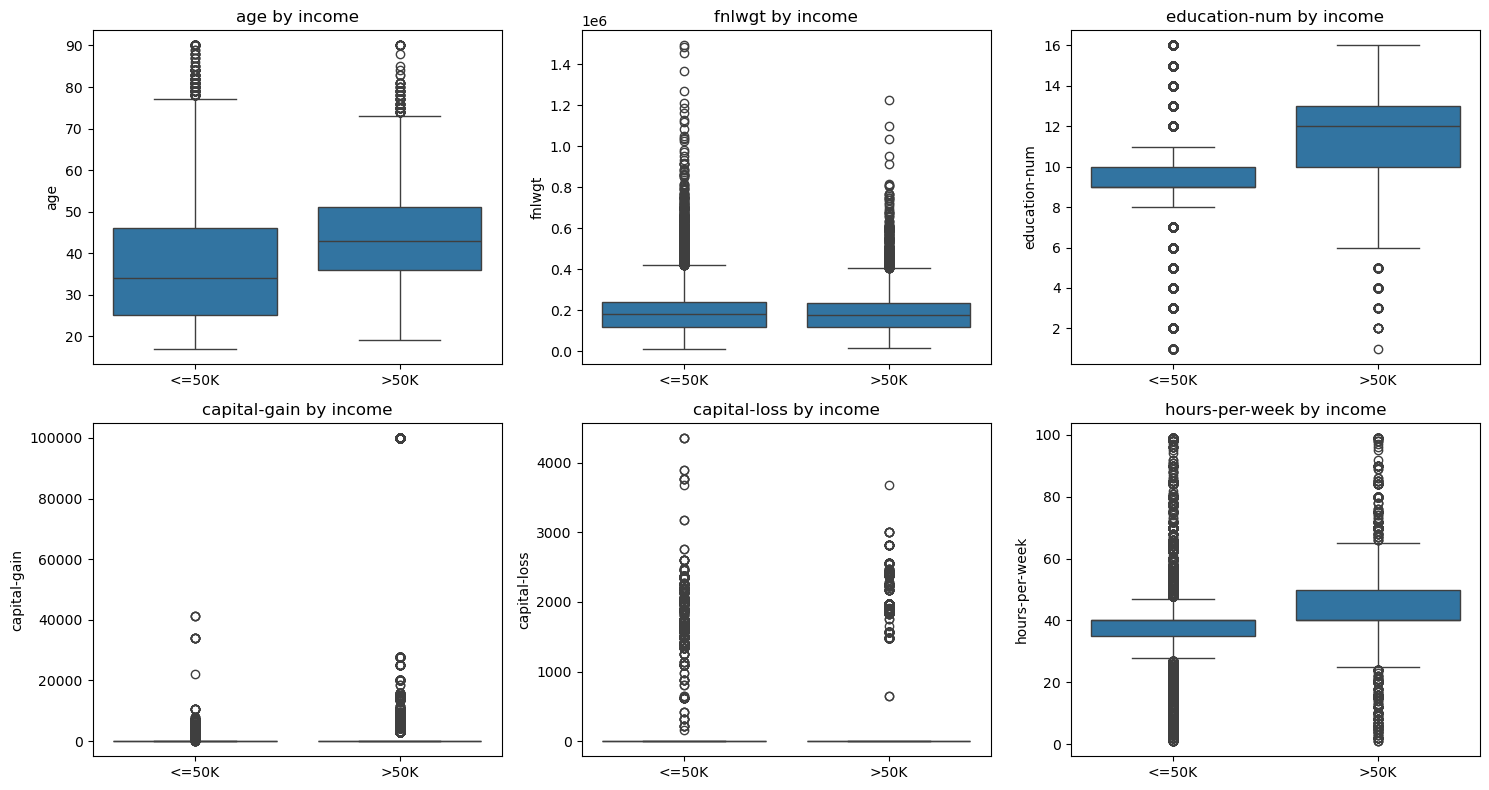

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=income_clean, y=df[col], ax=ax)
    ax.set_title(f"{col} by income")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

## 3.9 Variables numériques et revenu (boxplots)
- **`education-num`** : séparation la plus nette (médiane ≈ 12 pour `>50K` contre ≈ 9 pour `<=50K`).
- **`age`** : le groupe `>50K` est plus âgé (médiane ≈ 43 contre ≈ 34), avec un chevauchement.
- **`hours-per-week`** : le groupe `>50K` travaille plus (boîte de 40 à 50 h contre 35 à 40 h).
- **`fnlwgt`** : les deux boîtes sont quasi identiques, donc la variable ne sépare pas les classes.
- **`capital-gain` / `capital-loss`** : les boîtes sont aplaties à 0. La règle de l'IQR n'est pas pertinente ici, car toute valeur non nulle est signalée comme « aberrante ».

**Valeurs extrêmes** : `age` (jusqu'à 90) et `hours-per-week` (de 1 à 99) sont plausibles et ne sont pas des erreurs a priori.

In [20]:
print(pd.crosstab(df["capital-gain"] == 99999, income_clean))
print()
print(pd.crosstab(df["capital-gain"] > 0, income_clean, normalize="index").round(3))

income        <=50K   >50K
capital-gain              
False         37155  11443
True              0    244

income        <=50K   >50K
capital-gain              
False         0.795  0.205
True          0.383  0.617


## 3.10 Analyse de la valeur 99 999
Les 244 lignes avec `capital-gain = 99999` appartiennent **toutes** à la classe `>50K`. Cette valeur est probablement un plafonnement (top-coding) du recensement et porte un vrai signal.

De plus, parmi les personnes ayant un gain en capital > 0, **61,7 %** gagnent plus de 50K, contre **20,5 %** de celles sans gain : le simple fait d'avoir un gain est informatif, quel que soit le montant.

**Conséquence** : ces lignes ne doivent pas être supprimées comme des outliers. Un indicateur binaire et une transformation logarithmique permettent de conserver le signal tout en réduisant l'effet d'échelle.

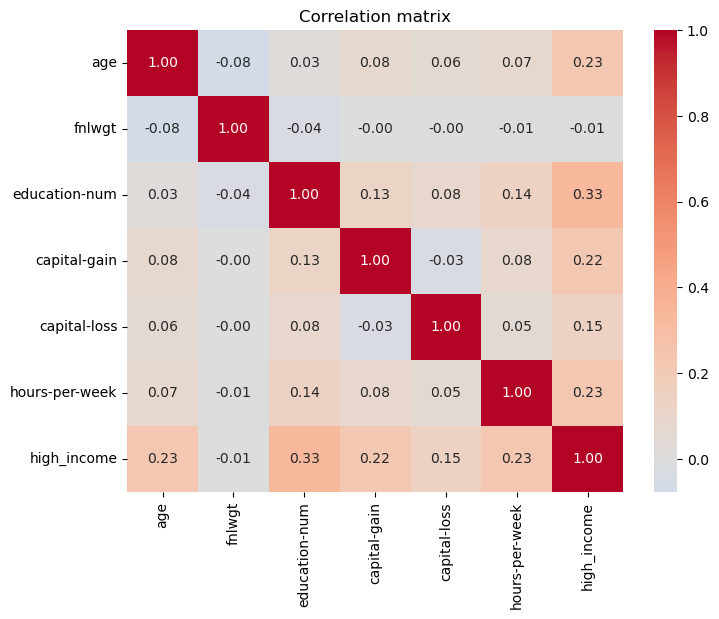

In [21]:
corr_df = df[num_cols].assign(high_income=(income_clean == ">50K").astype(int))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

## 3.11 Corrélations
- Corrélation avec la cible : `education-num` (0,33) est la plus forte, puis `age`, `hours-per-week` et `capital-gain` (≈ 0,22 à 0,23), `capital-loss` (0,15) et `fnlwgt` (≈ 0).
- Les corrélations entre variables numériques sont toutes faibles (maximum 0,14) : il n'y a pas de multicolinéarité parmi elles.
- Aucune variable ne domine : la prédiction du revenu nécessitera une combinaison de variables, en particulier les variables catégorielles.
- Limite : la corrélation de Pearson ne mesure que les relations linéaires. Elle sous-estime probablement l'effet de `capital-gain` (forte asymétrie, valeurs à 99 999).

## 3.12 Synthèse de l'exploration

| Constat | Traitement envisagé (à justifier en section 4) |
|---|---|
| `?` dans `workclass`, `occupation`, `native-country`, manquants ensemble et liés à un revenu plus faible | Convertir en `NaN`, puis traiter |
| Libellés de `income` avec un point final (fichier test) | Harmoniser |
| `fnlwgt` : aucun lien avec la cible, forte asymétrie | Supprimer |
| `education` redondante avec `education-num` | Garder `education-num` |
| `capital-gain` / `capital-loss` : > 90 % de zéros, skew 11,9 et 4,6, 99 999 tous `>50K` | Indicateur binaire + `log1p`, conserver les lignes à 99 999 |
| `native-country` : 90 % US, ~40 modalités rares | Regrouper |
| Catégories très rares | Regrouper |
| Chevauchement `relationship` / `marital-status` | À examiner |
| Déséquilibre de classes 76 % / 24 % | Séparation stratifiée, `class_weight`, F1 et ROC-AUC |

   # 4. Data Preparation

   Toutes les transformations sont appliquées sur une **copie** (`df_clean`) : le DataFrame brut `df` reste intact comme référence. Chaque choix ci-dessous s'appuie sur une observation de la section 3.

In [22]:
dups_all = df.duplicated().sum()
dups_no_weight = df.drop(columns=["fnlwgt", "source"]).duplicated().sum()

print("Exact duplicates (all columns):", dups_all)
print("Duplicates without fnlwgt:     ", dups_no_weight)

Exact duplicates (all columns): 29
Duplicates without fnlwgt:      4487


In [23]:
df_clean = df.copy()

# 1. Convert the hidden "?" into real missing values
df_clean = df_clean.replace("?", np.nan)

# 2. Harmonize the income labels (remove the trailing period)
df_clean["income"] = df_clean["income"].str.rstrip(".")

# 3. Remove the exact duplicates (all columns identical)
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Rows before:", n_before, "| after:", len(df_clean))

Rows before: 48842 | after: 48813


## 4.1 Nettoyage de base

**Conversion des `?` en valeurs manquantes.** Les `?` sont des valeurs manquantes déguisées en texte. Tant qu'elles restent des chaînes, pandas ne les voit pas, et elles seraient traitées comme une modalité ordinaire.

**Harmonisation de la cible.** Les libellés du fichier test se terminaient par un point (`<=50K.`, `>50K.`), ce qui créait quatre classes au lieu de deux. Après correction : 37 128 lignes `<=50K` et 11 685 lignes `>50K`.

**Doublons.** Deux contrôles ont été faits :
- **29 doublons exacts** (toutes colonnes identiques, `fnlwgt` compris) : cette colonne est quasi unique par personne, donc une coïncidence est très improbable. Ce sont de vrais doublons, **supprimés** (48 842 → 48 813 lignes). Les laisser pourrait faire apparaître la même ligne à la fois en train et en test, et gonfler artificiellement l'évaluation.
- **4 487 doublons si l'on ignore `fnlwgt`** : **conservés**. Avec seulement 14 variables, en majorité catégorielles, des personnes différentes partagent fréquemment le même profil. Les supprimer retirerait près de 9 % des données sur une fausse preuve.

Ce contrôle devait être fait **avant** de supprimer `fnlwgt`, qui est la colonne permettant de distinguer des profils semblables.

In [24]:
print(df_clean.isna().sum()[lambda s: s > 0])   # missing values per column
print(df_clean["income"].value_counts())          # should show only 2 labels

workclass         2799
occupation        2809
native-country     856
dtype: int64
income
<=50K    37128
>50K     11685
Name: count, dtype: int64


In [25]:
# workclass and occupation: dedicated "Unknown" category
for col in ["workclass", "occupation"]:
    df_clean[col] = df_clean[col].fillna("Unknown")

# native-country: mode imputation
mode_country = df_clean["native-country"].mode()[0]
print("Mode of native-country:", mode_country)
df_clean["native-country"] = df_clean["native-country"].fillna(mode_country)

Mode of native-country: United-States


In [26]:
print("Missing values left:", df_clean.isna().sum().sum())
print(df_clean["workclass"].value_counts().head(3))
print(df_clean["occupation"].value_counts().head(3))

Missing values left: 0
workclass
Private             33879
Self-emp-not-inc     3861
Local-gov            3136
Name: count, dtype: int64
occupation
Prof-specialty     6167
Craft-repair       6107
Exec-managerial    6084
Name: count, dtype: int64


## 4.2 Valeurs manquantes

| Variable | Traitement | Justification |
|---|---|---|
| `workclass` (2 799) | Catégorie **`Unknown`** | Absence structurelle, liée à un revenu plus faible (9,4 % de `>50K` contre 24,8 %). |
| `occupation` (2 809) | Catégorie **`Unknown`** | Mêmes lignes que `workclass` (+ 10 `Never-worked`). |
| `native-country` (856) | **Mode** (`United-States`) | 90 % des personnes sont américaines et aucun lien avec les autres variables n'a été observé. |

**Méthodes écartées :**
- *Suppression des lignes* : elle retirerait une sous-population précise (personnes sans emploi déclaré) et biaiserait l'analyse vers les actifs.
- *Imputation par le mode (`Private`) pour `workclass` / `occupation`* : elle ferait passer ces personnes pour des salariés du privé, alors que leur profil est très différent.

Pour `native-country`, le mode est une constante (≈ 90 % des lignes) : le calculer avant la séparation train/test n'introduit pas de fuite de données notable. Une imputation dépendant des données (moyenne, médiane) serait ajustée sur le train uniquement, dans un pipeline.

Après traitement : **0 valeur manquante**.

In [27]:
(df_clean[["workclass", "occupation"]] == "Unknown").sum()

workclass     2799
occupation    2809
dtype: int64

In [28]:
# native-country: US vs Non-US
df_clean["native-country"] = np.where(
    df_clean["native-country"] == "United-States", "US", "Non-US"
)

# Very rare categories merged with their closest meaning
df_clean["marital-status"] = df_clean["marital-status"].replace(
    {"Married-AF-spouse": "Married-civ-spouse"})

df_clean["occupation"] = df_clean["occupation"].replace(
    {"Armed-Forces": "Protective-serv"})

df_clean["workclass"] = df_clean["workclass"].replace(
    {"Never-worked": "No-pay", "Without-pay": "No-pay"})

In [29]:
for col in ["native-country", "marital-status", "occupation", "workclass"]:
    print(df_clean[col].value_counts())
    print()

native-country
US        44666
Non-US     4147
Name: count, dtype: int64

marital-status
Married-civ-spouse       22409
Never-married            16098
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Name: count, dtype: int64

occupation
Prof-specialty       6167
Craft-repair         6107
Exec-managerial      6084
Adm-clerical         5608
Sales                5504
Other-service        4919
Machine-op-inspct    3019
Unknown              2809
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1487
Tech-support         1445
Protective-serv       998
Priv-house-serv       240
Name: count, dtype: int64

workclass
Private             33879
Self-emp-not-inc     3861
Local-gov            3136
Unknown              2799
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
No-pay                 31
Name: count, dtype: int64



## 4.3 Regroupement de catégories

- **`native-country` → `US` / `Non-US`.** 90 % des lignes sont américaines et environ 40 autres pays pèsent chacun moins de 2 %. Un one-hot direct créerait une quarantaine de colonnes quasi vides (bruit, risque de surapprentissage). Après regroupement : `US` 44 666 lignes (91,5 %), `Non-US` 4 147. La part des États-Unis passe de 89,7 % à 91,5 % car les 856 valeurs imputées ont été affectées à `US`. *Alternative non retenue* : un regroupement par région, plus informatif mais qui demande une correspondance manuelle pays → région.
- **`Married-AF-spouse` → `Married-civ-spouse`** (0,1 % des lignes) : même situation maritale, effectif trop faible pour une catégorie propre.
- **`Armed-Forces` → `Protective-serv`** : métiers proches, et `Armed-Forces` ne comptait presque aucune ligne.
- **`Never-worked` et `Without-pay` → `No-pay`** (31 lignes) : deux catégories quasi vides au sens proche (aucune rémunération).

Les taux de revenu de ces catégories rares reposaient sur très peu de lignes et étaient donc peu fiables, ce qui justifie le regroupement.

In [30]:
# Binary indicators
df_clean["has_capital_gain"] = (df_clean["capital-gain"] > 0).astype(int)
df_clean["has_capital_loss"] = (df_clean["capital-loss"] > 0).astype(int)

# Log transform of the amounts
df_clean["capital-gain-log"] = np.log1p(df_clean["capital-gain"])
df_clean["capital-loss-log"] = np.log1p(df_clean["capital-loss"])

In [31]:
new_cols = ["capital-gain", "capital-gain-log", "capital-loss", "capital-loss-log"]
print(df_clean[new_cols].skew().round(2))
print()
print(df_clean[["has_capital_gain", "has_capital_loss"]].mean().round(3))

capital-gain        11.89
capital-gain-log     3.11
capital-loss         4.57
capital-loss-log     4.30
dtype: float64

has_capital_gain    0.083
has_capital_loss    0.047
dtype: float64


## 4.4 Feature engineering : gains et pertes en capital

`capital-gain` et `capital-loss` contiennent respectivement 91,7 % et 95,3 % de zéros, avec une asymétrie extrême (skewness de 11,89 et 4,57). Quatre variables sont créées :

- **`has_capital_gain` / `has_capital_loss`** (indicateurs 0/1) : 8,3 % et 4,7 % des personnes. Ils conservent le signal « a un gain / n'en a pas », qui est très informatif (61,7 % de `>50K` avec un gain, contre 20,5 % sans).
- **`capital-gain-log` / `capital-loss-log`** (`log1p`) : réduisent l'effet d'échelle sur les montants. On utilise `log1p` (log(1 + x)) car le logarithme simple n'est pas défini en 0.

| Variable | Skewness avant | Skewness après |
|---|---|---|
| `capital-gain` | 11,89 | 3,11 |
| `capital-loss` | 4,57 | 4,30 |

La transformation est **efficace pour `capital-gain`** mais **marginale pour `capital-loss`** : les pertes non nulles ne s'étalent que de ≈ 150 à 4 400, donc le logarithme les comprime peu, et l'asymétrie vient surtout du pic à 0. Pour `capital-loss`, l'information utile est donc surtout portée par l'indicateur.

**Les 244 lignes à 99 999 sont conservées.** Elles sont toutes `>50K` : il s'agit d'un plafonnement du recensement qui porte un vrai signal, et non d'une erreur. Les supprimer reviendrait à retirer de l'information, et la transformation logarithmique limite déjà leur effet d'échelle.

In [32]:
cols_to_drop = ["fnlwgt", "education", "capital-gain", "capital-loss"]
df_clean = df_clean.drop(columns=cols_to_drop)

print(df_clean.shape)
print(df_clean.columns.tolist())

(48813, 16)
['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'hours-per-week', 'native-country', 'income', 'source', 'has_capital_gain', 'has_capital_loss', 'capital-gain-log', 'capital-loss-log']


## 4.5 Suppression de colonnes

| Colonne | Raison |
|---|---|
| `fnlwgt` | Poids d'échantillonnage du recensement, pas une caractéristique de la personne. Corrélation avec la cible ≈ -0,01 et boîtes à moustaches identiques pour les deux classes. |
| `education` | Redondante avec `education-num`, qui est déjà ordonnée (le revenu augmente régulièrement avec elle), donc aucun encodage supplémentaire n'est nécessaire. |
| `capital-gain`, `capital-loss` | Remplacées par les indicateurs et les versions logarithmiques, pour éviter de garder deux versions de la même information. |

Le DataFrame final a la forme `(48813, 16)`.

In [33]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    k = min(table.shape) - 1
    return np.sqrt(chi2 / (n * k))

print("relationship vs marital-status:", round(cramers_v(df_clean["relationship"], df_clean["marital-status"]), 3))
print("relationship vs sex:           ", round(cramers_v(df_clean["relationship"], df_clean["sex"]), 3))
print("marital-status vs sex:         ", round(cramers_v(df_clean["marital-status"], df_clean["sex"]), 3))

relationship vs marital-status: 0.487
relationship vs sex:            0.647
marital-status vs sex:          0.458


In [34]:
pd.crosstab(df_clean["relationship"], df_clean["marital-status"])

marital-status,Divorced,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,
Husband,0,19709,0,0,0,0
Not-in-family,3626,23,330,7100,637,851
Other-relative,181,202,54,920,79,70
Own-child,455,144,61,6745,146,25
Unmarried,2368,0,183,1333,668,572
Wife,0,2331,0,0,0,0


## 4.6 Redondance entre `relationship` et `marital-status`

| Paire | V de Cramér |
|---|---|
| `relationship` / `marital-status` | 0,487 |
| `relationship` / `sex` | 0,647 |
| `marital-status` / `sex` | 0,458 |

Le chevauchement est **modéré**, pas total. La table de contingence montre pourquoi :
- Parmi les personnes mariées, `Husband` (19 709) et `Wife` (2 331) représentent 22 040 des 22 409 lignes `Married-civ-spouse` (≈ 98 %) : pour elles, `relationship` est essentiellement une réécriture de `sex`.
- Pour les autres, `relationship` apporte une information propre sur le rôle dans le foyer (`Own-child`, `Not-in-family`, `Unmarried`) que `marital-status` ne contient pas.

**Décision (provisoire, révisée en 6.6) : conserver les deux variables pour l'instant.** Supprimer `relationship` ferait perdre cette information. Deux précautions :
- Pour les personnes mariées, `relationship` sert de **proxy du sexe** : retirer `sex` seul n'éliminerait donc pas l'information de genre du modèle. À rappeler dans l'interprétation.
- Les modèles seront comparés avec et sans `relationship` pour vérifier empiriquement son apport.

## 4.7 Valeurs extrêmes : `age` et `hours-per-week`

Ces variables sont **conservées telles quelles**. Les valeurs observées (âges jusqu'à 90 ans, de 1 à 99 heures par semaine) sont plausibles. La règle de l'IQR en signalerait un grand nombre, mais ce sont des cas réels (retraités actifs, temps partiels, cumuls d'emplois) et non des erreurs de saisie. Les supprimer ou les plafonner appauvrirait les données sans justification métier. Le pic à 40 heures reflète la semaine de travail standard.

## 4.8 Encodage et mise à l'échelle (choix de méthode)

- **Variables catégorielles nominales** (`workclass`, `occupation`, `marital-status`, `race`, `sex`, `native-country`) : **encodage one-hot**. Ces modalités n'ont pas d'ordre naturel : un encodage ordinal (0, 1, 2, ...) en inventerait un et fausserait les distances du clustering et des modèles linéaires. (`relationship` est écartée : voir section 6.6.)
- **`education-num`** : déjà ordinale, utilisée telle quelle.
- **Variables numériques** (`age`, `education-num`, `hours-per-week`, `capital-gain-log`, `capital-loss-log`) : **`StandardScaler`** pour le clustering, la régression logistique et le KNN, qui reposent sur des distances ou des gradients sensibles à l'échelle. Pas de mise à l'échelle nécessaire pour les modèles à base d'arbres.
- **Absence de fuite de données** : pour la classification, l'encodage et la mise à l'échelle sont ajustés **uniquement sur le jeu d'entraînement**, dans un `Pipeline` / `ColumnTransformer`, puis appliqués au test.
- **Cible** : `income` codée 0/1 (`>50K` = 1).

Le fichier livrable `adult_prepared.csv` (section 4.9) contient le résultat de l'ensemble de ces transformations.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols_prep = ["age", "education-num", "hours-per-week",
                 "capital-gain-log", "capital-loss-log"]
bin_cols_prep = ["has_capital_gain", "has_capital_loss"]
cat_cols_prep = ["workclass", "marital-status", "occupation",
                 "race", "sex", "native-country"]      # relationship left out (see 6.6)

prep_final = ColumnTransformer(
    [("num", StandardScaler(), num_cols_prep),
     ("bin", "passthrough", bin_cols_prep),
     ("cat", OneHotEncoder(drop="if_binary"), cat_cols_prep)],
    sparse_threshold=0,
    verbose_feature_names_out=False,
)

df_prepared = pd.DataFrame(prep_final.fit_transform(df_clean),
                           columns=prep_final.get_feature_names_out(),
                           index=df_clean.index)

df_prepared["income"] = (df_clean["income"] == ">50K").astype(int)
df_prepared["source"] = df_clean["source"]

df_prepared.to_csv("adult_prepared.csv", index=False)

print(df_prepared.shape)
print("Missing values:", df_prepared.isna().sum().sum())
print(df_prepared[num_cols_prep].agg(["mean", "std"]).round(3))

(48813, 44)
Missing values: 0
      age  education-num  hours-per-week  capital-gain-log  capital-loss-log
mean -0.0           -0.0             0.0               0.0               0.0
std   1.0            1.0             1.0               1.0               1.0


## 4.9 Export des données préparées (livrable)

Le fichier **`adult_prepared.csv`** (48 813 lignes, 44 colonnes) contient les données nettoyées et préparées, après l'ensemble des transformations de la section 4 :

- **Nettoyage** : `?` convertis en valeurs manquantes puis traités (`Unknown` / mode), libellés de `income` harmonisés, 29 doublons exacts supprimés, catégories rares regroupées, `native-country` regroupée en `US` / `Non-US`.
- **Transformations** : indicateurs `has_capital_gain` / `has_capital_loss` et `log1p` des montants ; colonnes `fnlwgt`, `education`, `relationship` et montants bruts de capital retirées.
- **Standardisation** (`StandardScaler`) des cinq variables numériques : `age`, `education-num`, `hours-per-week`, `capital-gain-log`, `capital-loss-log`.
- **Encodage one-hot** des variables nominales (`workclass`, `marital-status`, `occupation`, `race`, `sex`, `native-country`).
- **Cible** : `income` codée 0/1 (`>50K` = 1), et colonne `source` (découpage officiel train/test).

Le fichier ne contient aucune valeur manquante. Les valeurs numériques étant standardisées, elles ne sont plus exprimées dans leur unité d'origine.

**Attention** : la standardisation et l'encodage sont ajustés ici sur l'**ensemble** des lignes. Ce fichier documente le résultat de la préparation et sert à la segmentation, qui n'a pas de séparation train/test. Pour la classification, ces transformations sont réalisées **dans des pipelines ajustés uniquement sur le jeu d'entraînement**, afin d'éviter toute fuite de données.

# 5. Segmentation

## Problématique
Identifier des **profils socio-économiques homogènes** dans la population du recensement, sans utiliser la cible `income`. Celle-ci sert uniquement **après coup** à vérifier que les segments ont un sens.

## Méthode
**K-Means**, adapté à des variables numériques et reposant sur des distances euclidiennes. Les variables catégorielles ne sont pas utilisées pour construire les segments ; elles servent à les décrire (section 5.7).

In [36]:
from sklearn.preprocessing import StandardScaler

seg_features = ["age", "education-num", "hours-per-week",
                "capital-gain-log", "capital-loss-log"]

X_seg = df_clean[seg_features]

scaler = StandardScaler()
X_seg_scaled = pd.DataFrame(scaler.fit_transform(X_seg),
                            columns=seg_features, index=X_seg.index)

print(X_seg_scaled.mean().round(3))
print(X_seg_scaled.std().round(3))

age                -0.0
education-num      -0.0
hours-per-week      0.0
capital-gain-log    0.0
capital-loss-log    0.0
dtype: float64
age                 1.0
education-num       1.0
hours-per-week      1.0
capital-gain-log    1.0
capital-loss-log    1.0
dtype: float64


## 5.1 Choix des variables et mise à l'échelle

Un premier jeu de variables est retenu : `age`, `education-num`, `hours-per-week`, `capital-gain-log` et `capital-loss-log`.

**Mise à l'échelle (`StandardScaler`).** K-Means regroupe les points selon la distance euclidienne : sans mise à l'échelle, une variable à grande amplitude (`age`, de 17 à 90) dominerait les autres. Après standardisation, chaque variable a une moyenne de 0 et un écart-type de 1 (vérifié).

**Pas de fuite de données.** La segmentation n'a pas de séparation train/test : ajuster le scaler sur l'ensemble des lignes ne pose donc pas de problème. La règle « ajuster sur le train uniquement » s'applique à la classification.

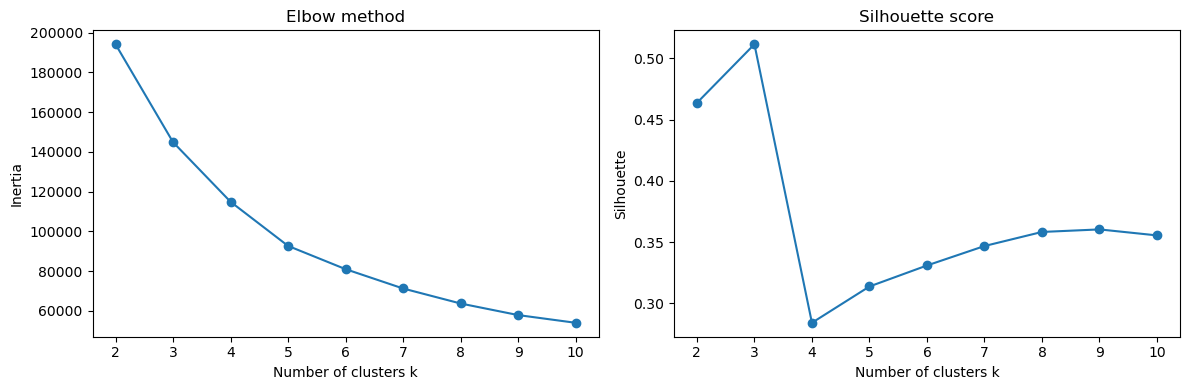

    k   inertia  silhouette
0   2  194112.0       0.464
1   3  144889.0       0.511
2   4  114910.0       0.284
3   5   92723.0       0.314
4   6   81037.0       0.331
5   7   71316.0       0.347
6   8   63770.0       0.358
7   9   57951.0       0.360
8  10   54068.0       0.355


In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_seg_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg_scaled, labels,
                                        sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

print(pd.DataFrame({"k": k_range, "inertia": np.round(inertias), "silhouette": np.round(silhouettes, 3)}))

## 5.2 Choix du nombre de clusters (premier jeu de variables)

K-Means exige `k` à l'avance. Deux critères sont utilisés pour `k` de 2 à 10 (`n_init=10`, `random_state=42`) :
- **Méthode du coude** : l'inertie (somme des carrés des distances aux centres) diminue toujours quand `k` augmente ; on cherche le point où le gain devient faible.
- **Score de silhouette** : mesure dans quelle mesure chaque point est plus proche de son cluster que du cluster voisin (de -1 à 1, plus c'est haut, mieux c'est). Il est calculé sur un échantillon de 10 000 points pour limiter le temps de calcul.

**Résultats :**
- Le coude est progressif, sans point d'inflexion net.
- La silhouette est maximale pour **k = 3 (0,511)**, puis **k = 2 (0,464)**, et s'effondre à k = 4 (0,284).

In [38]:
km3 = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_k3 = pd.Series(km3.fit_predict(X_seg_scaled), index=df_clean.index, name="cluster")

print(labels_k3.value_counts().sort_index())
print()

profile = df_clean.groupby(labels_k3).agg(
    age=("age", "mean"),
    education_num=("education-num", "mean"),
    hours=("hours-per-week", "mean"),
    pct_capital_gain=("has_capital_gain", "mean"),
    pct_capital_loss=("has_capital_loss", "mean"),
)
profile["pct_high_income"] = (df_clean["income"] == ">50K").groupby(labels_k3).mean()
print(profile.round(2))

cluster
0    42501
1     2282
2     4030
Name: count, dtype: int64

           age  education_num  hours  pct_capital_gain  pct_capital_loss  \
cluster                                                                    
0        37.96           9.94  39.98               0.0               0.0   
1        41.80          10.98  43.27               0.0               1.0   
2        44.13          11.07  43.53               1.0               0.0   

         pct_high_income  
cluster                   
0                   0.19  
1                   0.50  
2                   0.62  


## 5.3 Analyse de la solution k = 3 : un résultat trivial

Le score de silhouette de k = 3 est élevé, mais le profil des clusters montre que la segmentation est triviale :

| Cluster | Effectif | Caractéristique | % `>50K` |
|---|---|---|---|
| 0 | 42 501 (87 %) | ni gain ni perte en capital | 19 % |
| 1 | 2 282 (4,7 %) | tous ont une perte en capital | 50 % |
| 2 | 4 030 (8,3 %) | tous ont un gain en capital | 62 % |

- Les effectifs correspondent exactement aux parts de `has_capital_gain` (8,3 %) et `has_capital_loss` (4,7 %) : le modèle a seulement séparé « gain », « perte » et « aucun des deux ».
- Après standardisation, les valeurs non nulles de `capital-gain-log` et `capital-loss-log` (92 % et 95 % de zéros) sont très éloignées du reste, ce qui donne des groupes bien séparés, donc une silhouette élevée.
- Âge, éducation et heures varient peu entre les clusters (38 à 44 ans, 10 à 11 années d'études, 40 à 43,5 h).

**Conclusion** : une silhouette élevée mesure la séparation, pas l'intérêt des segments. Les variables de capital conviennent mieux à la **description** des segments qu'à leur construction. Elles sont donc retirées du clustering.

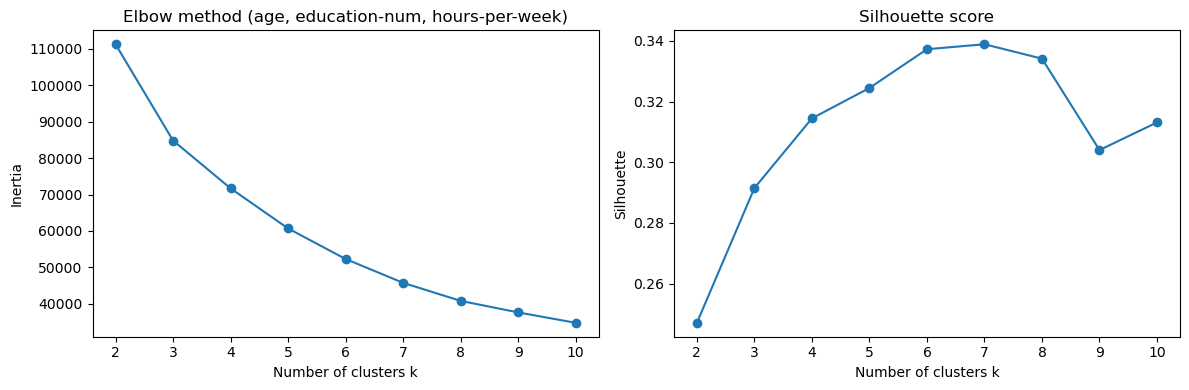

    k   inertia  silhouette
0   2  111294.0       0.247
1   3   84847.0       0.292
2   4   71716.0       0.314
3   5   60698.0       0.324
4   6   52309.0       0.337
5   7   45754.0       0.339
6   8   40802.0       0.334
7   9   37634.0       0.304
8  10   34777.0       0.313


In [39]:
seg_features_v2 = ["age", "education-num", "hours-per-week"]

X_seg2 = df_clean[seg_features_v2]
X_seg2_scaled = pd.DataFrame(StandardScaler().fit_transform(X_seg2),
                             columns=seg_features_v2, index=X_seg2.index)

inertias2, silhouettes2 = [], []

for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_seg2_scaled)
    inertias2.append(km.inertia_)
    silhouettes2.append(silhouette_score(X_seg2_scaled, labels,
                                         sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 11), inertias2, marker="o")
axes[0].set_title("Elbow method (age, education-num, hours-per-week)")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")

axes[1].plot(range(2, 11), silhouettes2, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

print(pd.DataFrame({"k": range(2, 11),
                    "inertia": np.round(inertias2),
                    "silhouette": np.round(silhouettes2, 3)}))

## 5.4 Second jeu de variables : `age`, `education-num`, `hours-per-week`

Le clustering est refait sur ces trois variables, standardisées de la même façon.

| k | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|
| Silhouette | 0,247 | 0,292 | 0,314 | 0,324 | **0,337** | **0,339** | 0,334 | 0,304 | 0,313 |

- Le coude reste progressif, sans point d'inflexion net.
- La silhouette monte jusqu'à un **plateau pour k = 6 à 8** (≈ 0,34) puis baisse. Les valeurs (0,25 à 0,34) indiquent une structure faible à modérée, ce qui est normal : âge, éducation et heures forment un nuage continu, sans coupure naturelle.
- Les écarts entre k = 5 et k = 8 (≈ 0,01) sont de l'ordre du bruit d'estimation sur un échantillon de 10 000 points : les critères ne permettent pas de trancher, et l'interprétabilité des clusters décide.

Ces scores sont plus bas que ceux de la section 5.2, mais portent sur des clusters qui décrivent réellement le profil des personnes.

In [40]:
def profile_k(k):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lab = pd.Series(km.fit_predict(X_seg2_scaled), index=df_clean.index, name="cluster")

    prof = df_clean.groupby(lab).agg(
        size=("age", "size"),
        age=("age", "mean"),
        education_num=("education-num", "mean"),
        hours=("hours-per-week", "mean"),
        pct_capital_gain=("has_capital_gain", "mean"),
        pct_capital_loss=("has_capital_loss", "mean"),
    )
    prof["pct_high_income"] = (df_clean["income"] == ">50K").groupby(lab).mean()
    prof["pct_male"] = (df_clean["sex"] == "Male").groupby(lab).mean()
    return lab, prof.round(2)

labels_k4, profile_k4 = profile_k(4)
labels_k6, profile_k6 = profile_k(6)

print(profile_k4)
print()
print(profile_k6)

          size    age  education_num  hours  pct_capital_gain  \
cluster                                                         
0         5798  39.49          10.01  60.76              0.10   
1        11807  54.27           8.52  36.73              0.09   
2        18887  27.55           8.99  35.33              0.04   
3        12321  40.28          13.27  42.20              0.13   

         pct_capital_loss  pct_high_income  pct_male  
cluster                                               
0                    0.06             0.35      0.84  
1                    0.04             0.22      0.66  
2                    0.03             0.07      0.60  
3                    0.07             0.46      0.69  

          size    age  education_num  hours  pct_capital_gain  \
cluster                                                         
0        16622  30.84           9.29  41.24              0.06   
1         3278  47.26           4.46  38.61              0.05   
2         4934  23

## 5.5 Choix de k : comparaison de k = 4 et k = 6

**k = 4** (coude peu marqué) :

| Taille | Âge | Éducation | Heures | % `>50K` | Lecture |
|---|---|---|---|---|---|
| 18 887 (38,7 %) | 27,6 | 9,0 | 35,3 | 7 % | jeunes |
| 11 807 (24,2 %) | 54,3 | 8,5 | 36,7 | 22 % | plus âgés, éducation plus faible |
| 12 321 (25,2 %) | 40,3 | 13,3 | 42,2 | 46 % | très diplômés |
| 5 798 (11,9 %) | 39,5 | 10,0 | 60,8 | 35 % | très longues heures |

**k = 6** (début du plateau de silhouette, 0,337) : six segments nommés d'après leur profil moyen (voir la heatmap 5.6 et le tableau 5.7).

**Décision : k = 6.**
- Il **sépare des groupes que k = 4 fusionne** : le grand groupe de jeunes (38,7 %) se scinde en jeunes actifs à temps plein (13 % de `>50K`) et jeunes à temps partiel (3 %), très différents en heures et en revenu. Le groupe à très faible niveau d'études (6,7 %) apparaît aussi, alors qu'il était noyé dans le cluster des plus âgés.
- Tous les segments restent **assez grands** (le plus petit compte 3 278 personnes) et **faciles à nommer**.
- Le score de silhouette est légèrement meilleur (0,337 contre 0,314), mais l'écart est faible : l'argument principal est l'interprétabilité.
- Les variables de capital ne pilotent plus le résultat : `has_capital_gain` reste entre 3 % et 13 % selon les segments, proche des 8,3 % globaux.

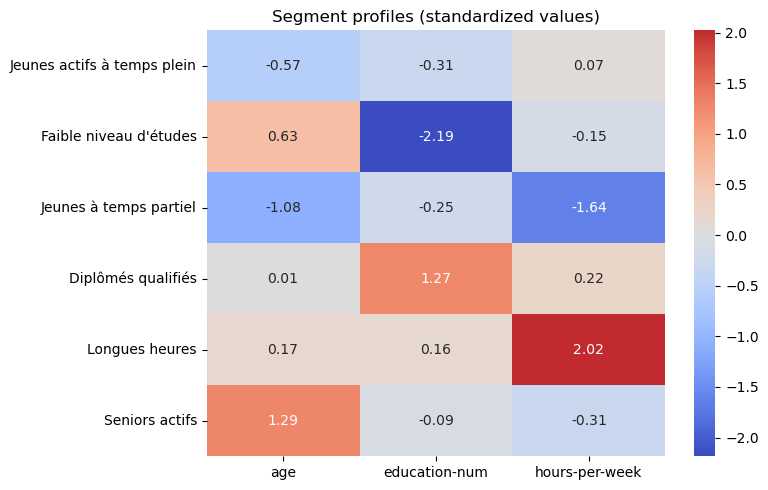

In [41]:
seg_names = {0: "Jeunes actifs à temps plein", 1: "Faible niveau d'études",
             2: "Jeunes à temps partiel", 3: "Diplômés qualifiés",
             4: "Longues heures", 5: "Seniors actifs"}

# Cluster centres, in standard deviations from the population mean
centers = X_seg2_scaled.groupby(labels_k6).mean()
centers.index = centers.index.map(seg_names)

plt.figure(figsize=(8, 5))
sns.heatmap(centers, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Segment profiles (standardized values)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5.6 Visualisation des segments

La heatmap montre l'écart de chaque segment à la moyenne de la population (en écarts-types) : positif (rouge) = au-dessus de la moyenne, négatif (bleu) = en dessous, au-delà de ±1 = écart marqué.

Chaque segment se distingue par une ou deux variables fortes :
- **Longues heures** : `hours-per-week` +2,02.
- **Faible niveau d'études** : `education-num` -2,19.
- **Jeunes à temps partiel** : `age` -1,08 et `hours-per-week` -1,64.
- **Seniors actifs** : `age` +1,29.
- **Diplômés qualifiés** : `education-num` +1,27.
- **Jeunes actifs à temps plein** : plus jeunes que la moyenne (`age` -0,57), avec un volume d'heures proche de la moyenne.

Ces écarts justifient le nom donné à chaque segment. Les noms décrivent les moyennes des segments : un segment peut contenir des personnes dont le profil s'en écarte.

Les segments ne sont pas nettement séparés : âge, éducation et heures forment un nuage continu que K-Means découpe en régions, ce qui est cohérent avec un score de silhouette modéré (0,337).

In [42]:
seg = labels_k6.map(seg_names).rename("segment")

# Share of each category inside each segment (rows add up to 100%)
for col in ["sex", "marital-status", "workclass", "native-country"]:
    print(f"--- {col} (% within each segment) ---")
    print((pd.crosstab(seg, df_clean[col], normalize="index") * 100).round(1))
    print()

# Occupation has 14 categories, so we show the top 3 per segment
print("--- Top 3 occupations per segment ---")
for name, grp in df_clean.groupby(seg):
    top = grp["occupation"].value_counts(normalize=True).head(3).mul(100).round(1)
    print(name, "->", ", ".join(f"{o} ({p}%)" for o, p in top.items()))

--- sex (% within each segment) ---
sex                          Female  Male
segment                                  
Diplômés qualifiés             30.3  69.7
Faible niveau d'études         28.0  72.0
Jeunes actifs à temps plein    32.6  67.4
Jeunes à temps partiel         56.6  43.4
Longues heures                 15.6  84.4
Seniors actifs                 34.3  65.7

--- marital-status (% within each segment) ---
marital-status               Divorced  Married-civ-spouse  \
segment                                                     
Diplômés qualifiés               12.3                53.5   
Faible niveau d'études           12.9                53.3   
Jeunes actifs à temps plein      13.7                38.4   
Jeunes à temps partiel            5.4                12.2   
Longues heures                   12.8                64.2   
Seniors actifs                   19.8                58.0   

marital-status               Married-spouse-absent  Never-married  Separated  \
segment    

## 5.7 Profil des segments sur les variables catégorielles

Les variables catégorielles (`sex`, `marital-status`, `workclass`, `native-country`, `occupation`) n'ont **pas** été utilisées pour construire les segments. Elles permettent donc de les décrire et de vérifier qu'ils ont un sens.

| Segment | Taille | % `>50K` | Profil |
|---|---|---|---|
| Jeunes actifs à temps plein | 16 622 (34,1 %) | 13 % | 31 ans, ~41 h. 42,2 % célibataires et 38,4 % mariés (groupe de transition). Secteur privé à 78,8 %, métiers : `Craft-repair`, `Adm-clerical`. |
| Faible niveau d'études | 3 278 (6,7 %) | 7 % | Éducation très faible (4,5 années en moyenne). 28,4 % d'origine hors États-Unis (population : 8,5 %). Métiers manuels et de service. |
| Jeunes à temps partiel | 4 934 (10,1 %) | 3 % | 24 ans, ~20 h. 79,1 % célibataires, seul segment à majorité féminine (56,6 %). `Other-service` et `Sales`. 13,7 % sans `workclass` connu. |
| Diplômés qualifiés | 10 775 (22,1 %) | 47 % | Éducation élevée (13,4). `Prof-specialty` (37,2 %) et `Exec-managerial` (23,9 %). 22,4 % dans la fonction publique. |
| Longues heures | 3 944 (8,1 %) | 38 % | ~65 h par semaine. 84,4 % d'hommes, 64,2 % de mariés, 30,7 % de travailleurs indépendants (population : ~11 %). |
| Seniors actifs | 9 260 (19,0 %) | 28 % | 56 ans. 58,0 % mariés, 19,8 % divorcés, 10,7 % veufs. Métiers proches de la population générale : segment défini surtout par l'âge. |

**Lecture.**
- Le taux de revenus `>50K` varie de 3 % à 47 % selon les segments, alors que `income` n'a pas servi au clustering : les segments capturent de vraies différences socio-économiques.
- Les écarts de genre apparaissent sans que `sex` soit utilisée : les heures travaillées sont l'une des voies par lesquelles l'écart de revenu entre hommes et femmes observé en section 3 se manifeste. Il s'agit d'une association dans des données de 1994, pas d'une preuve de causalité.
- Les deux segments de jeunes ne se décrivent pas de la même manière : le temps partiel est quasi exclusivement célibataire, le temps plein est mixte.
- Les 856 pays manquants ayant été imputés à `US`, les parts américaines sont très légèrement surestimées.

**Limite.** Les segments reposent sur trois variables seulement (`age`, `education-num`, `hours-per-week`) et ne sont pas nettement séparés (silhouette de 0,337) : ils découpent un nuage continu et doivent être lus comme des tendances, pas comme des catégories strictes.

# 6. Classification

## Problématique
Prédire si le revenu annuel d'une personne dépasse 50 000 $ (`income` = `>50K`, codé 1) à partir de ses caractéristiques.

## 6.1 Cible, variables et séparation train/test
- **Cible** : `income` convertie en 0/1 (`>50K` = 1). Classe positive : 23,9 % des lignes.
- **Variables** : les 14 variables préparées en section 4. `income` (cible) et `source` (colonne technique) sont exclues.
- **Séparation** : le découpage **officiel** du dataset (`adult.data` pour l'entraînement, `adult.test` pour le test) est conservé. Les deux parties sont très proches (part de `>50K` : 24,1 % en train contre 23,6 % en test ; âge, éducation et heures quasi identiques), donc ce découpage ne présente pas de biais visible. Il constitue le découpage de référence du dataset et permet de comparer les résultats à ceux de la littérature.
- **Jeu de test** : utilisé **une seule fois**, à la fin, sur le modèle retenu. Le choix des modèles et des hyperparamètres se fait par **validation croisée sur le jeu d'entraînement**, pour que le score final ne soit pas optimiste.

In [43]:
y = (df_clean["income"] == ">50K").astype(int)
X = df_clean.drop(columns=["income", "source"])

train_mask = df_clean["source"] == "train"
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[~train_mask], y[~train_mask]

print(X_train.shape, X_test.shape)
print("Share of >50K in train:", y_train.mean().round(3))
print("Share of >50K in test: ", y_test.mean().round(3))
print(X_train.columns.tolist())

(32537, 14) (16276, 14)
Share of >50K in train: 0.241
Share of >50K in test:  0.236
['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'hours-per-week', 'native-country', 'has_capital_gain', 'has_capital_loss', 'capital-gain-log', 'capital-loss-log']


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

num_cols_clf = ["age", "education-num", "hours-per-week",
                "capital-gain-log", "capital-loss-log"]
bin_cols_clf = ["has_capital_gain", "has_capital_loss"]
cat_cols_clf = ["workclass", "marital-status", "occupation",
                "relationship", "race", "sex", "native-country"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols_clf),
    ("bin", "passthrough", bin_cols_clf),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_cols_clf),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]

models = {
    "Dummy (always <=50K)": DummyClassifier(strategy="most_frequent"),
    "Logistic regression":  LogisticRegression(max_iter=1000),
}

rows = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name, **{m: res[f"test_{m}"].mean() for m in scoring}})

print(pd.DataFrame(rows).round(3).set_index("model"))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklea

                      accuracy  precision  recall     f1  roc_auc  \
model                                                               
Dummy (always <=50K)     0.759      0.000   0.000  0.000    0.500   
Logistic regression      0.851      0.733   0.597  0.658    0.907   

                      average_precision  
model                                    
Dummy (always <=50K)              0.241  
Logistic regression               0.766  


## 6.2 Prétraitement et modèles de référence

**Pipeline** (`ColumnTransformer` + modèle), ajusté **uniquement sur les données d'entraînement** à chaque pli de la validation croisée, afin d'éviter toute fuite de données :
- variables numériques (`age`, `education-num`, `hours-per-week`, `capital-gain-log`, `capital-loss-log`) : `StandardScaler` ;
- indicateurs 0/1 (`has_capital_gain`, `has_capital_loss`) : laissés tels quels ;
- variables catégorielles nominales : encodage **one-hot** (`handle_unknown="ignore"`, `drop="if_binary"`).

**Évaluation** : validation croisée stratifiée à 5 plis sur le jeu d'entraînement (la part de `>50K` est conservée dans chaque pli), avec accuracy, précision, rappel, F1, ROC-AUC et PR-AUC.

| Modèle | Accuracy | Précision | Rappel | F1 | ROC-AUC | PR-AUC
|---|---|---|---|---|---|---|
| Dummy (toujours `<=50K`) | 0,759 | 0,000 | 0,000 | 0,000 | 0,500 | 0,241
| Régression logistique | 0,851 | 0,733 | 0,597 | 0,658 | 0,907 | 0,766

Le modèle Dummy atteint 75,9 % d'accuracy **sans trouver aucun** revenu élevé : l'accuracy seule est donc trompeuse sur cette cible déséquilibrée. La régression logistique gagne environ 9 points d'accuracy et a un bon ROC-AUC (0,907), mais son rappel est faible (0,597) : elle manque environ 40 % des revenus `>50K`.
Le **PR-AUC** (aire sous la courbe précision-rappel) mesure la qualité du classement de la classe `>50K`. Un modèle sans aucune capacité obtient environ la proportion de positifs, soit **0,241** (ligne Dummy) : la régression logistique, à 0,766, fait environ trois fois mieux que cette référence.

In [45]:
models_v2 = {
    "Logistic regression (balanced)": LogisticRegression(max_iter=1000, class_weight="balanced"),
}

for name, model in models_v2.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name, **{m: res[f"test_{m}"].mean() for m in scoring}})

print(pd.DataFrame(rows).round(3).set_index("model"))

                                accuracy  precision  recall     f1  roc_auc  \
model                                                                         
Dummy (always <=50K)               0.759      0.000   0.000  0.000    0.500   
Logistic regression                0.851      0.733   0.597  0.658    0.907   
Logistic regression (balanced)     0.810      0.571   0.848  0.682    0.907   

                                average_precision  
model                                              
Dummy (always <=50K)                        0.241  
Logistic regression                         0.766  
Logistic regression (balanced)              0.764  


## 6.3 Gestion du déséquilibre de classes

Avec seulement 24 % de `>50K`, le modèle hésite à prédire la classe minoritaire. `class_weight="balanced"` pondère les erreurs sur cette classe en proportion de sa rareté, sans modifier les données.

| Modèle | Accuracy | Précision | Rappel | F1 | ROC-AUC | PR-AUC
|---|---|---|---|---|---|---|
| Régression logistique | 0,851 | 0,733 | 0,597 | 0,658 | 0,907 | 0,766
| Régression logistique (pondérée) | 0,810 | 0,571 | 0,848 | 0,682 | 0,907 | 0,764

- Le **rappel** passe de 0,597 à 0,848, au prix d'une **précision** plus faible (0,733 → 0,571) et d'une accuracy en baisse, ce qui est attendu : l'accuracy favorise la classe majoritaire.
- Le **ROC-AUC reste identique** (0,907) et le PR-AUC varie à peine (0,766 → 0,764) : la pondération n'altère quasiment pas le classement des personnes, elle déplace surtout le point d'équilibre entre précision et rappel.
- Pour comparer les modèles, on privilégie donc le **F1-score** et le **ROC-AUC**.

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models_v3 = {
    "Decision tree (depth 8, balanced)": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=42),
    "Random forest (balanced)": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5, class_weight="balanced_subsample",
        n_jobs=-1, random_state=42),
}

for name, model in models_v3.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name, **{m: res[f"test_{m}"].mean() for m in scoring}})

print(pd.DataFrame(rows).round(3).set_index("model"))

                                   accuracy  precision  recall     f1  \
model                                                                   
Dummy (always <=50K)                  0.759      0.000   0.000  0.000   
Logistic regression                   0.851      0.733   0.597  0.658   
Logistic regression (balanced)        0.810      0.571   0.848  0.682   
Decision tree (depth 8, balanced)     0.804      0.561   0.858  0.678   
Random forest (balanced)              0.828      0.601   0.844  0.702   

                                   roc_auc  average_precision  
model                                                          
Dummy (always <=50K)                 0.500              0.241  
Logistic regression                  0.907              0.766  
Logistic regression (balanced)       0.907              0.764  
Decision tree (depth 8, balanced)    0.902              0.745  
Random forest (balanced)             0.919              0.804  


## 6.4 Modèles à base d'arbres

| Modèle | Accuracy | Précision | Rappel | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| Régression logistique (pondérée) | 0,810 | 0,571 | 0,848 | 0,682 | 0,907 | 0,764 |
| Arbre de décision (profondeur 8, pondéré) | 0,804 | 0,561 | 0,858 | 0,678 | 0,902 | 0,745 |
| Forêt aléatoire (pondérée) | 0,828 | 0,601 | 0,844 | **0,702** | **0,919** | **0,804** |

- La **forêt aléatoire** obtient le meilleur F1 et le meilleur ROC-AUC, avec une précision supérieure à celle des autres modèles pour un rappel équivalent. Elle peut capturer des **interactions** entre variables (par exemple âge et éducation) que le modèle linéaire ne représente pas.
- L'**arbre de décision** et la **régression logistique pondérée** sont proches en F1 (écart de 0,004) et en ROC-AUC (0,005) ; en PR-AUC, l'arbre est un peu plus faible (0,745 contre 0,764). La variation entre plis n'ayant pas été mesurée pour cette métrique, on ne conclut pas sur la significativité de cet écart.
- L'avance de la forêt est plus nette en PR-AUC (+0,04 sur la régression logistique) qu'en ROC-AUC (+0,012) : elle classe mieux les personnes à revenu élevé, ce qui est l'enjeu de ce problème.
- La forêt gagne environ 0,017 de ROC-AUC sur l'arbre seul : c'est l'effet habituel de la moyenne de nombreux arbres.

In [47]:
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",
                                   n_jobs=-1, random_state=42)),
])

param_grid = {
    "clf__max_depth": [10, 16, None],
    "clf__min_samples_leaf": [3, 5, 10],
}

grid = GridSearchCV(rf_pipe, param_grid, cv=cv,
                    scoring={"f1": "f1", "roc_auc": "roc_auc"},
                    refit="f1", n_jobs=1, verbose=1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))

results = pd.DataFrame(grid.cv_results_)[
    ["param_clf__max_depth", "param_clf__min_samples_leaf",
     "mean_test_f1", "std_test_f1", "mean_test_roc_auc"]
].sort_values("mean_test_f1", ascending=False)
print(results.round(3).to_string(index=False))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'clf__max_depth': None, 'clf__min_samples_leaf': 3}
Best CV F1: 0.709
param_clf__max_depth  param_clf__min_samples_leaf  mean_test_f1  std_test_f1  mean_test_roc_auc
                None                            3         0.709        0.003              0.919
                None                            5         0.702        0.002              0.919
                  16                            3         0.698        0.002              0.919
                  16                            5         0.694        0.001              0.918
                None                           10         0.694        0.002              0.917
                  16                           10         0.690        0.002              0.916
                  10                            3         0.675        0.002              0.913
                  10                            5         0.674        0.003        

## 6.5 Optimisation des hyperparamètres de la forêt aléatoire

`GridSearchCV` (validation croisée à 5 plis sur le jeu d'entraînement, critère : F1) sur `max_depth` ∈ {10, 16, None} et `min_samples_leaf` ∈ {3, 5, 10} (9 combinaisons, 45 ajustements).

| max_depth | `min_samples_leaf` = 3 | 5 | 10 |
|---|---|---|---|
| None | **0,709** | 0,702 | 0,694 |
| 16 | 0,698 | 0,694 | 0,690 |
| 10 | 0,675 | 0,674 | 0,673 |

**Meilleure combinaison : `max_depth=None`, `min_samples_leaf=3`** (F1 = 0,709).
- Les arbres plus profonds et les feuilles plus petites sont meilleurs : la moyenne de 200 arbres absorbe le surapprentissage individuel, et le détail supplémentaire capte une vraie structure.
- La variation entre plis est faible (écart-type du F1 de 0,001 à 0,003) : l'avantage de la meilleure combinaison sur la suivante (+0,007) est probablement réel mais modeste.
- Le ROC-AUC est identique (0,919) pour les trois premières combinaisons : le gain de F1 vient du **point d'équilibre précision/rappel**, pas d'un meilleur classement des personnes.
- **Limite** : la meilleure combinaison se situe au bord de la grille (profondeur illimitée, plus petite taille de feuille testée). Un optimum légèrement au-delà (`min_samples_leaf` de 1 ou 2) n'est pas exclu, mais l'AUC étant plate sur les premières lignes, le gain attendu est faible.
- Le score de 0,709 est mesuré sur les mêmes plis que ceux utilisés pour la sélection : il est légèrement optimiste. Le jeu de test fournira l'estimation non biaisée.

In [48]:
best_params = {k.replace("clf__", ""): v for k, v in grid.best_params_.items()}

def make_rf_pipeline(cat_cols):
    prep = ColumnTransformer([
        ("num", StandardScaler(), num_cols_clf),
        ("bin", "passthrough", bin_cols_clf),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_cols),
    ])
    rf = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",
                                n_jobs=-1, random_state=42, **best_params)
    return Pipeline([("prep", prep), ("clf", rf)])

variants = {
    "With relationship": cat_cols_clf,
    "Without relationship": [c for c in cat_cols_clf if c != "relationship"],
}

rows_rel = []
for name, cols in variants.items():
    res = cross_validate(make_rf_pipeline(cols), X_train, y_train, cv=cv, scoring=scoring)
    rows_rel.append({"variant": name,
                     **{m: res[f"test_{m}"].mean() for m in scoring},
                     "f1_std": res["test_f1"].std()})

print(pd.DataFrame(rows_rel).round(3).set_index("variant"))

                      accuracy  precision  recall     f1  roc_auc  \
variant                                                             
With relationship        0.836      0.620   0.826  0.709    0.919   
Without relationship     0.839      0.626   0.822  0.710    0.919   

                      average_precision  f1_std  
variant                                          
With relationship                 0.805   0.003  
Without relationship              0.806   0.004  


## 6.6 Expérience : la variable `relationship` est-elle utile ?

En section 4.6, `relationship` et `marital-status` présentaient un chevauchement modéré (V de Cramér = 0,487), et `relationship` agit comme proxy du sexe pour les personnes mariées. La forêt optimisée est comparée avec et sans cette variable (mêmes plis, jeu d'entraînement). **La règle de décision a été fixée avant l'expérience** : si la différence de F1 est de l'ordre d'un écart-type (≈ 0,003), on retire la variable.

| Variante | Accuracy | Précision | Rappel | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Avec `relationship` | 0,836 | 0,620 | 0,826 | 0,709 | 0,919 |
| Sans `relationship` | 0,839 | 0,626 | 0,822 | 0,710 | 0,919 |

La différence de F1 (0,001) est inférieure à la variation entre plis (0,003 à 0,004) et le ROC-AUC est identique : les deux versions sont indiscernables. **`relationship` est donc retirée** : le modèle est plus simple, et l'une des deux voies par lesquelles l'information de genre atteignait le modèle disparaît.

Précisions : `sex` reste une variable du modèle, donc l'information de genre n'est pas supprimée ; et les hyperparamètres ont été optimisés avec `relationship`, puis réutilisés sans elle (écart négligeable au vu du résultat).

              precision    recall  f1-score   support

       <=50K      0.937     0.846     0.889     12430
        >50K      0.621     0.817     0.706      3846

    accuracy                          0.839     16276
   macro avg      0.779     0.831     0.798     16276
weighted avg      0.863     0.839     0.846     16276

ROC-AUC: 0.919
PR-AUC: 0.804


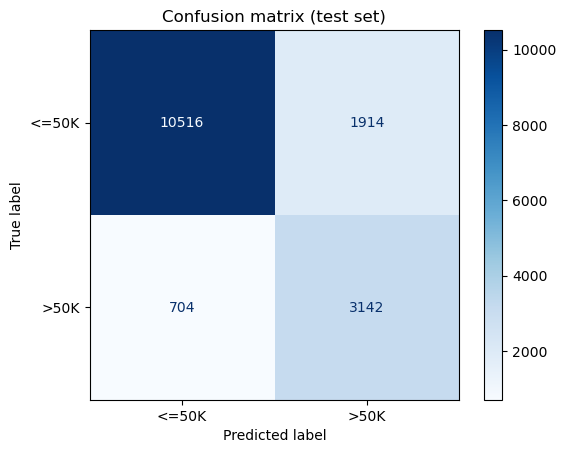

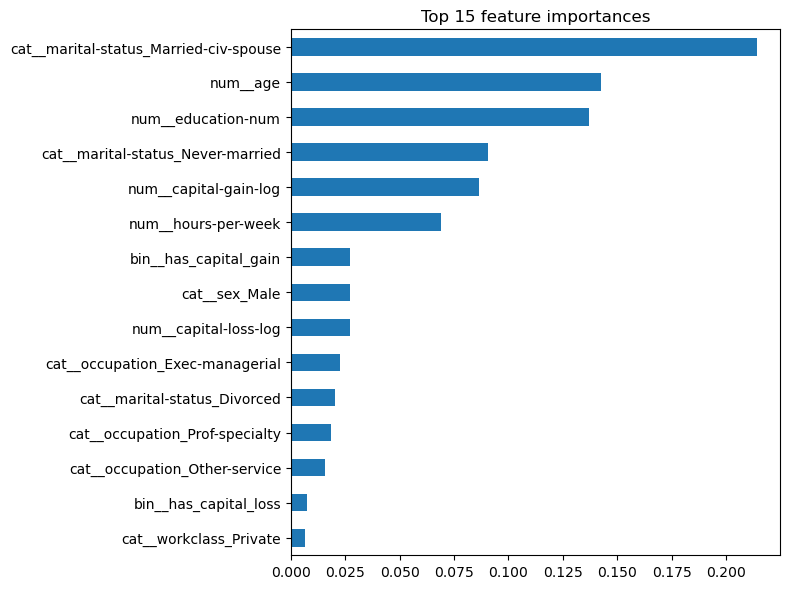

In [49]:
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_auc_score, average_precision_score)

final_cols = [c for c in cat_cols_clf if c != "relationship"]
final_model = make_rf_pipeline(final_cols)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"], digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=["<=50K", ">50K"], cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.show()

# Most important features
names = final_model.named_steps["prep"].get_feature_names_out()
imp = pd.Series(final_model.named_steps["clf"].feature_importances_, index=names)
imp.sort_values().tail(15).plot(kind="barh", figsize=(8, 6), title="Top 15 feature importances")
plt.tight_layout()
plt.show()

## 6.7 Évaluation finale sur le jeu de test

Le modèle retenu (forêt aléatoire pondérée, `max_depth=None`, `min_samples_leaf=3`, sans `relationship`) est entraîné sur l'ensemble du jeu d'entraînement, puis évalué **une seule fois** sur le jeu de test (16 276 personnes).

| Métrique (classe `>50K`) | Validation croisée | Test |
|---|---|---|
| F1 | 0,710 | 0,706 |
| Rappel | 0,822 | 0,817 |
| Précision | 0,626 | 0,621 |
| ROC-AUC | 0,919 | 0,919 |
| Accuracy | 0,839 | 0,839 |
| PR-AUC | non mesuré | 0,804 |

L'écart entre validation croisée et test est inférieur à 0,005 sur toutes les métriques : pas de signe de surapprentissage ni de fuite de données.

**Matrice de confusion** :

| | Prédit `<=50K` | Prédit `>50K` |
|---|---|---|
| **Réel `<=50K`** (12 430) | 10 516 | 1 914 (faux positifs) |
| **Réel `>50K`** (3 846) | 704 (faux négatifs) | 3 142 |

- Le modèle retrouve **81,7 %** des revenus élevés (3 142 sur 3 846) ; quand il prédit `>50K`, il a raison **62,1 %** du temps.
- Il prédit `>50K` 5 056 fois pour 3 846 cas réels : c'est l'effet de la pondération des classes, qui privilégie le rappel au détriment de la précision.

**Importance des variables** (importance par impureté de la forêt) :
- `marital-status` est la variable la plus importante : ses modalités `Married-civ-spouse` (≈ 0,21), `Never-married` (≈ 0,09) et `Divorced` (≈ 0,02) totalisent environ 0,32, devant `age` (≈ 0,14) et `education-num` (≈ 0,14).
- Les variables de capital pèsent ensemble environ 0,11 et `hours-per-week` environ 0,07.
- `sex` (≈ 0,03) est utilisée par le modèle.

Cette importance est répartie sur les colonnes issues du one-hot d'une même variable et favorise les variables numériques : elle donne un ordre de grandeur et non un classement exact. Elle mesure l'usage de la variable par le modèle, pas un effet causal.

In [50]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, confusion_matrix

# Out-of-fold probabilities on the training set (the test set is not used)
oof = cross_val_predict(final_model, X_train, y_train, cv=cv,
                        method="predict_proba")[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
t_star = thr[f1s.argmax()]
print("Tuned threshold:", round(t_star, 3), "| CV F1 at that threshold:", round(f1s.max(), 3))

# Single comparison on the test set: default vs. tuned threshold
for t, label in [(0.5, "threshold 0.5"), (t_star, "tuned threshold")]:
    pred = (y_proba >= t).astype(int)
    print(f"\n--- {label} ({t:.3f}) ---")
    print(classification_report(y_test, pred, digits=3))
    print(confusion_matrix(y_test, pred))

y_pred_final = (y_proba >= t_star).astype(int)   # used by the fairness tables

Tuned threshold: 0.583 | CV F1 at that threshold: 0.72

--- threshold 0.5 (0.500) ---
              precision    recall  f1-score   support

           0      0.937     0.846     0.889     12430
           1      0.621     0.817     0.706      3846

    accuracy                          0.839     16276
   macro avg      0.779     0.831     0.798     16276
weighted avg      0.863     0.839     0.846     16276

[[10516  1914]
 [  704  3142]]

--- tuned threshold (0.583) ---
              precision    recall  f1-score   support

           0      0.919     0.890     0.904     12430
           1      0.678     0.747     0.711      3846

    accuracy                          0.856     16276
   macro avg      0.798     0.819     0.808     16276
weighted avg      0.862     0.856     0.859     16276

[[11064  1366]
 [  973  2873]]


## 6.8 Ajustement du seuil de décision

Par défaut, une personne est prédite `>50K` si sa probabilité estimée dépasse 0,5. Le seuil est ici choisi pour maximiser le F1, à partir de **prédictions hors-plis sur le jeu d'entraînement** (`cross_val_predict`, 5 plis) : le jeu de test n'intervient pas dans ce choix.

**Seuil retenu : 0,583** (F1 en validation croisée à ce seuil : 0,72, légèrement optimiste car c'est le maximum observé sur ces mêmes prédictions).

| Métrique (classe `>50K`, test) | Seuil 0,5 | Seuil 0,583 |
|---|---|---|
| Précision | 0,621 | 0,678 |
| Rappel | 0,817 | 0,747 |
| F1 | 0,706 | 0,711 |
| Accuracy | 0,839 | 0,856 |
| Faux positifs / faux négatifs | 1 914 / 704 | 1 366 / 973 |

- Le seuil optimal est **supérieur à 0,5** : la pondération des classes (`balanced_subsample`) tire les probabilités vers le haut, et relever le seuil compense en partie cet effet.
- Le **gain de F1 est très faible (+0,005)**. Le changement de seuil déplace surtout le compromis : 548 fausses alertes en moins, au prix de 269 hauts revenus manqués en plus. Le modèle prédit 4 239 `>50K` pour 3 846 cas réels (contre 5 056 à 0,5).
- Le choix du seuil dépend du coût des erreurs : 0,5 pour retrouver le plus possible de hauts revenus, 0,583 pour limiter les fausses alertes. Les deux lignes sont rapportées, et le seuil n'a pas été choisi d'après les scores du test.

In [51]:
def group_report(attr, y_true, y_pred):
    rows = []
    for v in X_test[attr].unique():
        m = (X_test[attr] == v).values
        tn, fp, fn, tp = confusion_matrix(y_true[m], y_pred[m], labels=[0, 1]).ravel()
        rows.append({attr: v, "n": m.sum(),
                     "actual >50K rate": y_true[m].mean(),
                     "predicted >50K rate": y_pred[m].mean(),
                     "recall": tp / (tp + fn) if tp + fn else np.nan,
                     "false positive rate": fp / (fp + tn) if fp + tn else np.nan,
                     "precision": tp / (tp + fp) if tp + fp else np.nan})
    return pd.DataFrame(rows).set_index(attr).round(3)

for g in ["sex", "race"]:
    print(f"\n--- By {g} ---")
    display(group_report(g, y_test.values, y_pred_final))


--- By sex ---


,n,actual >50K rate,predicted >50K rate,recall,false positive rate,precision
sex,,,,,,
Male,10856,0.300,0.341,0.767,0.158,0.675
Female,5420,0.109,0.099,0.636,0.034,0.696



--- By race ---


,n,actual >50K rate,predicted >50K rate,recall,false positive rate,precision
race,,,,,,
Black,1561,0.115,0.113,0.682,0.039,0.693
White,13941,0.250,0.279,0.753,0.121,0.676
Asian-Pac-Islander,480,0.277,0.298,0.729,0.133,0.678
Other,135,0.185,0.111,0.560,0.009,0.933
Amer-Indian-Eskimo,159,0.119,0.088,0.579,0.021,0.786


## 6.9 Analyse par sous-groupes (équité)

Les métriques sont calculées par groupe sur le jeu de test, avec le seuil de 0,583.

**Par sexe**

| Groupe | n | % `>50K` réel | % `>50K` prédit | Rappel | Taux de faux positifs | Précision |
|---|---|---|---|---|---|---|
| Hommes | 10 856 | 30,0 % | 34,1 % | 0,767 | 0,158 | 0,675 |
| Femmes | 5 420 | 10,9 % | 9,9 % | 0,636 | 0,034 | 0,696 |

- Le **rappel** est inférieur de 13 points pour les femmes : le modèle manque davantage de leurs hauts revenus.
- Le **taux de faux positifs** est environ 4,6 fois plus élevé pour les hommes : leurs bas revenus sont plus souvent classés à tort `>50K`.
- La **précision** est proche (0,675 contre 0,696) : une prédiction `>50K` est à peu près aussi fiable dans les deux groupes.
- Le modèle surestime la part de hauts revenus chez les hommes (34,1 % prédit contre 30,0 % réel) et la sous-estime légèrement chez les femmes.
- Les taux d'erreur sont inégaux alors que la précision est presque égale. Quand les taux réels diffèrent entre groupes (30,0 % contre 10,9 %), il est en général impossible d'égaliser à la fois la précision et les taux d'erreur.

**Par origine ethnique**

| Groupe | n | % `>50K` réel | % `>50K` prédit | Rappel | Taux de faux positifs | Précision |
|---|---|---|---|---|---|---|
| White | 13 941 | 25,0 % | 27,9 % | 0,753 | 0,121 | 0,676 |
| Black | 1 561 | 11,5 % | 11,3 % | 0,682 | 0,039 | 0,693 |
| Asian-Pac-Islander | 480 | 27,7 % | 29,8 % | 0,729 | 0,133 | 0,678 |
| Other | 135 | 18,5 % | 11,1 % | 0,560 | 0,009 | 0,933 |
| Amer-Indian-Eskimo | 159 | 11,9 % | 8,8 % | 0,579 | 0,021 | 0,786 |

- Entre `Black` et `White`, le rappel est inférieur d'environ 7 points (0,682 contre 0,753) et le taux de faux positifs est trois fois plus faible (0,039 contre 0,121). La part prédite correspond au taux réel pour `Black` (11,3 % contre 11,5 %), alors qu'elle est supérieure pour `White` (27,9 % contre 25,0 %).
- `Asian-Pac-Islander` (480 personnes) se rapproche de `White`.
- `Other` et `Amer-Indian-Eskimo` reposent sur environ 25 et 19 personnes à revenu élevé : une seule personne change le rappel de 4 à 5 points. **Aucune conclusion n'est possible** pour ces groupes.

**Limites de cette analyse.**
- Ces chiffres sont **descriptifs** : aucun intervalle de confiance n'est calculé, et les écarts faibles entre groupes de petite taille ne sont pas interprétables.
- Un seul seuil global est utilisé pour tous les groupes.
- `sex` reste une variable du modèle, et des variables corrélées (`marital-status`, `occupation`) peuvent jouer le rôle de proxys : retirer la variable sensible ne suffirait pas à supprimer les écarts. Le modèle n'a pas été réentraîné sans `sex` pour le tester.
- Les écarts décrits reflètent aussi des écarts présents dans les données de 1994 : ce sont des associations, pas des preuves de causalité.

# 7. Évaluation et interprétation des résultats

## Synthèse du parcours
1. **Exploration** : les `?` cachés, les libellés incohérents du fichier de test, la forte asymétrie des variables de capital et le déséquilibre de la cible (76 % / 24 %) ont été identifiés avant tout traitement.
2. **Préparation** : chaque choix a été justifié par une observation (catégorie `Unknown` plutôt que suppression, regroupement de `native-country`, indicateurs + `log1p` pour le capital, conservation des lignes à 99 999, suppression de `fnlwgt` et `education`, suppression de 29 doublons exacts).
3. **Segmentation** : K-Means sur `age`, `education-num` et `hours-per-week` (k = 6). Un premier essai incluant les variables de capital produisait une segmentation triviale malgré une silhouette élevée (0,511).
4. **Classification** : forêt aléatoire optimisée, F1 = 0,706 et ROC-AUC = 0,919 sur le jeu de test, stables par rapport à la validation croisée. PR-AUC = 0,804 ; seuil ajusté à 0,583 (F1 = 0,711)

## Interprétation
- Le revenu est lié principalement à la **situation maritale, l'âge, le niveau d'études, les gains en capital et les heures travaillées**, ce qui est cohérent avec l'exploration (section 3) et avec la segmentation : les segments « Diplômés qualifiés » (47 % de `>50K`) et « Longues heures » (38 %) s'opposent aux « Jeunes à temps partiel » (3 %).
- Les deux approches se recoupent sans se confondre : la segmentation n'utilise pas la cible, et pourtant le taux de `>50K` varie de 3 % à 47 % selon les segments.

## Limites
- **Données de 1994, États-Unis** : les résultats ne se transposent pas tels quels à une autre époque ou un autre pays.
- **Compromis précision / rappel** : au seuil de 0,583, le modèle retrouve 74,7 % des revenus élevés et 32 % de ses prédictions `>50K` sont fausses ; au seuil de 0,5, il en retrouve 81,7 % mais 38 % de ses prédictions sont fausses. Le gain de F1 du seuil ajusté est faible (+0,005), et le bon équilibre dépend du coût des erreurs.
- **Équité** : au seuil de 0,583, le rappel est plus faible pour les femmes (0,636 contre 0,767) et le taux de faux positifs plus élevé pour les hommes (0,158 contre 0,034) ; le rappel est aussi plus faible pour `Black` (0,682) que pour `White` (0,753). Ces écarts reflètent en partie ceux des données de 1994 et sont des associations, pas des preuves de causalité. Les groupes `Other` et `Amer-Indian-Eskimo` sont trop petits pour conclure, et aucun intervalle de confiance n'est calculé.
- **Segmentation** : trois variables seulement et des segments non nettement séparés (silhouette 0,337) ; les segments sont des tendances et non des catégories strictes.
- **Hyperparamètres** : l'optimum se trouve en bordure de grille.

## Pistes d'amélioration
Essayer le gradient boosting ; réentraîner sans `sex` et comparer les écarts entre groupes ; ajouter des intervalles de confiance aux métriques par groupe ; tester un clustering mixte (K-Prototypes) intégrant les variables catégorielles.

